# AI/ML Model Training - Code Examples

This notebook accompanies `Chapter_AI_ML_Training.md`.

It turns the chapter's examples into executable notebook cells. Most examples use a synthetic manufacturing inspection dataset so the notebook can run without downloading external files.

The notebook covers:

- Problem framing and requirements
- Stratified, grouped, and time-based splitting
- K-fold cross-validation
- Baselines and model comparison
- Training pipelines
- MLflow and TensorBoard tracking patterns
- Hyperparameter tuning
- Early stopping and loss curves
- Decision thresholds
- Bagging, boosting, and stacking ensembles
- Compute resources, job submission patterns, GPU checks, and distributed training concepts
- Reproducibility

## Dependencies

This notebook uses common data science packages:

```shell
pip install numpy pandas scipy scikit-learn matplotlib
```

Optional tracking and deep-learning examples use:

```shell
pip install mlflow torch tensorboard
```

The MLflow, TensorBoard, and PyTorch cells include `try` / `except` blocks so the rest of the notebook can still be read if those optional packages are not installed.

## 1. Setup and Synthetic Inspection Dataset

The chapter examples refer to features such as voltage, travel speed, material, shift, batch IDs, and pass/fail inspection labels. This cell creates a small synthetic dataset with those fields.

The label is intentionally imbalanced: failures are less common than passes.

In [1]:
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_classification, make_regression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    GroupShuffleSplit,
    KFold,
    RandomizedSearchCV,
    StratifiedKFold,
    TimeSeriesSplit,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from scipy.stats import randint

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Setup complete")

Setup complete


In [2]:
n_samples = 1000

X_numeric, y = make_classification(
    n_samples=n_samples,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=2,
    weights=[0.94, 0.06],
    class_sep=1.2,
    random_state=RANDOM_SEED,
)

df = pd.DataFrame(
    X_numeric,
    columns=["voltage", "travel_speed", "temperature", "mean_pixel"],
)

# Convert synthetic numeric features into manufacturing-like ranges.
df["voltage"] = 22 + df["voltage"] * 1.8
df["travel_speed"] = 5 + df["travel_speed"] * 0.7
df["temperature"] = 450 + df["temperature"] * 35
df["mean_pixel"] = 120 + df["mean_pixel"] * 20

rng = np.random.default_rng(RANDOM_SEED)
df["material"] = rng.choice(["steel", "alloy", "aluminum"], size=n_samples, p=[0.55, 0.30, 0.15])
df["shift"] = rng.choice(["day", "night"], size=n_samples, p=[0.65, 0.35])

# This manufacturing feature is included to demonstrate stratifying on a non-target feature.
df["operator_group"] = rng.choice(
    ["trainee", "standard", "experienced"],
    size=n_samples,
    p=[0.15, 0.55, 0.30],
)

df["batch_id"] = [f"batch_{i // 10:03d}" for i in range(n_samples)]
df["inspection_date"] = pd.date_range("2026-01-01", periods=n_samples, freq="h")
df["inspection_result"] = np.where(y == 1, "fail", "pass")

df.head()

,voltage,travel_speed,temperature,mean_pixel,material,shift,operator_group,batch_id,inspection_date,inspection_result
0,24.106358,4.082861,484.684565,97.798372,alloy,day,experienced,batch_000,2026-01-01 00:00:00,pass
1,22.357624,6.189455,457.147183,143.762467,steel,day,standard,batch_000,2026-01-01 01:00:00,fail
2,25.052301,3.400972,458.778374,104.184366,aluminum,day,experienced,batch_000,2026-01-01 02:00:00,pass
3,21.043382,4.741511,404.487334,71.504267,alloy,day,standard,batch_000,2026-01-01 03:00:00,pass
4,22.349293,3.124460,453.395501,146.370443,steel,day,trainee,batch_000,2026-01-01 04:00:00,pass


In [3]:
target = "inspection_result"
feature_columns = ["voltage", "travel_speed", "temperature", "mean_pixel", "material", "shift"]

X = df[feature_columns]
y = df[target].map({"pass": 0, "fail": 1})
batch_ids = df["batch_id"]

print("Class balance:")
print(df[target].value_counts())
print("\nClass balance percentage:")
print(df[target].value_counts(normalize=True).round(3))

Class balance:
inspection_result
pass    938
fail     62
Name: count, dtype: int64

Class balance percentage:
inspection_result
pass    0.938
fail    0.062
Name: proportion, dtype: float64


## 2. Problem Statement and Requirements

A training notebook should begin with the practical problem, not the algorithm.

Example problem statement:

> We want to identify inspection records that are likely to contain critical defects so inspectors can prioritize review.

Functional requirements describe what the model must do. Non-functional requirements describe how the model must behave in the real system.

In [4]:
requirements = pd.DataFrame(
    {
        "requirement_type": [
            "functional",
            "functional",
            "functional",
            "non-functional",
            "non-functional",
            "non-functional",
        ],
        "requirement": [
            "Predict pass/fail inspection result",
            "Return a probability-like failure score",
            "Support threshold tuning for review capacity",
            "Run quickly enough for inspection workflow",
            "Be explainable enough for review meetings",
            "Train on available CPU or shared GPU resources",
        ],
    }
)

requirements

,requirement_type,requirement
0,functional,Predict pass/fail inspection result
1,functional,Return a probability-like failure score
2,functional,Support threshold tuning for review capacity
3,non-functional,Run quickly enough for inspection workflow
4,non-functional,Be explainable enough for review meetings
5,non-functional,Train on available CPU or shared GPU resources


## 3. Intelligent Dataset Splitting

This section shows the chapter's main split types:

- Stratified splitting for class balance
- Grouped splitting when related examples must stay together
- Time-based splitting when future data should come after past data
- Fitting transformations only after splitting

In [5]:
# Stratified 70% / 15% / 15% split.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_SEED,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_SEED,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(y_train), len(y_val), len(y_test)],
        "failure_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    }
)

split_summary

,split,rows,failure_rate
0,train,700,0.061429
1,validation,150,0.066667
2,test,150,0.060000


### Stratifying on a Non-Target Feature

The target label is often the best stratification column, but sometimes you also need balanced representation for another important feature. This example uses `operator_group`, which could represent groups such as `trainee`, `standard`, and `experienced`. The same pattern can apply to `site`, `machine_type`, `material`, or `shift`.

In [6]:
# Stratify on a non-target feature: operator_group.
X_train_operator, X_test_operator, y_train_operator, y_test_operator = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=df["operator_group"],
    random_state=RANDOM_SEED,
)

pd.DataFrame(
    {
        "split": ["full dataset", "train", "test"],
        "trainee_rate": [
            (df["operator_group"] == "trainee").mean(),
            (df.loc[X_train_operator.index, "operator_group"] == "trainee").mean(),
            (df.loc[X_test_operator.index, "operator_group"] == "trainee").mean(),
        ],
        "experienced_rate": [
            (df["operator_group"] == "experienced").mean(),
            (df.loc[X_train_operator.index, "operator_group"] == "experienced").mean(),
            (df.loc[X_test_operator.index, "operator_group"] == "experienced").mean(),
        ],
        "failure_rate": [y.mean(), y_train_operator.mean(), y_test_operator.mean()],
    }
).round(3)

,split,trainee_rate,experienced_rate,failure_rate
0,full dataset,0.159,0.285,0.062
1,train,0.159,0.285,0.060
2,test,0.160,0.285,0.070


In [7]:
# Stratify on both the target and operator_group by creating a combined strata column.
combined_strata = y.astype(str) + "_" + df["operator_group"].astype(str)

X_train_combo, X_test_combo, y_train_combo, y_test_combo = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=combined_strata,
    random_state=RANDOM_SEED,
)

summary_rows = []
for split_name, indices, labels in [
    ("full dataset", df.index, y),
    ("train", X_train_combo.index, y_train_combo),
    ("test", X_test_combo.index, y_test_combo),
]:
    summary_rows.append(
        {
            "split": split_name,
            "rows": len(indices),
            "trainee_rate": (df.loc[indices, "operator_group"] == "trainee").mean(),
            "experienced_rate": (df.loc[indices, "operator_group"] == "experienced").mean(),
            "failure_rate": labels.mean(),
        }
    )

pd.DataFrame(summary_rows).round(3)

,split,rows,trainee_rate,experienced_rate,failure_rate
0,full dataset,1000,0.159,0.285,0.062
1,train,800,0.159,0.285,0.062
2,test,200,0.160,0.285,0.060


### Resampling Strategies

Resampling should be applied only to the training data. The validation and test sets should usually keep the natural distribution so evaluation reflects the real world.

In [8]:
train_for_resampling = X_train.copy()
train_for_resampling["target"] = y_train

majority = train_for_resampling[train_for_resampling["target"] == 0]
minority = train_for_resampling[train_for_resampling["target"] == 1]

minority_oversampled = minority.sample(
    n=len(majority),
    replace=True,
    random_state=RANDOM_SEED,
)
oversampled_train = pd.concat([majority, minority_oversampled]).sample(
    frac=1,
    random_state=RANDOM_SEED,
)

majority_undersampled = majority.sample(
    n=len(minority),
    replace=False,
    random_state=RANDOM_SEED,
)
undersampled_train = pd.concat([majority_undersampled, minority]).sample(
    frac=1,
    random_state=RANDOM_SEED,
)

pd.DataFrame(
    {
        "dataset": ["original training", "oversampled training", "undersampled training", "validation unchanged"],
        "rows": [len(train_for_resampling), len(oversampled_train), len(undersampled_train), len(y_val)],
        "failure_rate": [
            train_for_resampling["target"].mean(),
            oversampled_train["target"].mean(),
            undersampled_train["target"].mean(),
            y_val.mean(),
        ],
    }
).round(3)

,dataset,rows,failure_rate
0,original training,700,0.061
1,oversampled training,1314,0.500
2,undersampled training,86,0.500
3,validation unchanged,150,0.067


In [9]:
# Grouped split: keep all records from a batch together.
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED,
)

train_idx, grouped_test_idx = next(splitter.split(X, y, groups=batch_ids))

grouped_train_batches = set(batch_ids.iloc[train_idx])
grouped_test_batches = set(batch_ids.iloc[grouped_test_idx])

overlap = grouped_train_batches.intersection(grouped_test_batches)

print(f"Grouped train rows: {len(train_idx)}")
print(f"Grouped test rows: {len(grouped_test_idx)}")
print(f"Overlapping batches between train and test: {len(overlap)}")

Grouped train rows: 800
Grouped test rows: 200
Overlapping batches between train and test: 0


In [10]:
# Time-based split: earlier records train the model, later records evaluate it.
df_sorted = df.sort_values("inspection_date").reset_index(drop=True)

train_end = int(len(df_sorted) * 0.70)
val_end = int(len(df_sorted) * 0.85)

time_train = df_sorted.iloc[:train_end]
time_val = df_sorted.iloc[train_end:val_end]
time_test = df_sorted.iloc[val_end:]

pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "start_date": [time_train.inspection_date.min(), time_val.inspection_date.min(), time_test.inspection_date.min()],
        "end_date": [time_train.inspection_date.max(), time_val.inspection_date.max(), time_test.inspection_date.max()],
        "rows": [len(time_train), len(time_val), len(time_test)],
    }
)

,split,start_date,end_date,rows
0,train,2026-01-01 00:00:00,2026-01-30 03:00:00,700
1,validation,2026-01-30 04:00:00,2026-02-05 09:00:00,150
2,test,2026-02-05 10:00:00,2026-02-11 15:00:00,150


In [11]:
# Fit preprocessing on training data only, then transform validation and test data.
scaler = StandardScaler()

numeric_features = ["voltage", "travel_speed", "temperature", "mean_pixel"]

scaler.fit(X_train[numeric_features])
X_train_scaled = scaler.transform(X_train[numeric_features])
X_val_scaled = scaler.transform(X_val[numeric_features])
X_test_scaled = scaler.transform(X_test[numeric_features])

print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)
print("Training means after scaling:", X_train_scaled.mean(axis=0).round(6))

(700, 4) (150, 4) (150, 4)
Training means after scaling: [ 0. -0. -0.  0.]


## 4. K-Fold Cross-Validation

K-fold cross-validation trains and validates a model multiple times using different folds. This gives a more stable estimate than a single split, especially when data is limited.

Use:

- `StratifiedKFold` for classification with class balance
- `KFold` for many regression problems
- `GroupKFold` when related records must stay together
- `TimeSeriesSplit` for ordered data

In [12]:
cv_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced"),
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED,
)

cv_scores = cross_validate(
    cv_model,
    X[numeric_features],
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=True,
)

pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall", "f1"],
        "mean_validation_score": [
            cv_scores["test_accuracy"].mean(),
            cv_scores["test_precision"].mean(),
            cv_scores["test_recall"].mean(),
            cv_scores["test_f1"].mean(),
        ],
        "std_validation_score": [
            cv_scores["test_accuracy"].std(),
            cv_scores["test_precision"].std(),
            cv_scores["test_recall"].std(),
            cv_scores["test_f1"].std(),
        ],
    }
).round(3)

,metric,mean_validation_score,std_validation_score
0,accuracy,0.931,0.025
1,precision,0.489,0.091
2,recall,0.903,0.063
3,f1,0.628,0.080


In [13]:
# Other cross-validation strategies from the chapter.
print("KFold regression-style splits:")
for fold, (train_index, val_index) in enumerate(KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED).split(X), start=1):
    print(f"Fold {fold}: train={len(train_index)}, validation={len(val_index)}")

print("\nGroupKFold splits with batch IDs:")
for fold, (train_index, val_index) in enumerate(GroupKFold(n_splits=3).split(X, y, groups=batch_ids), start=1):
    train_groups = set(batch_ids.iloc[train_index])
    val_groups = set(batch_ids.iloc[val_index])
    print(f"Fold {fold}: overlap_groups={len(train_groups.intersection(val_groups))}")

print("\nTimeSeriesSplit keeps validation after training:")
for fold, (train_index, val_index) in enumerate(TimeSeriesSplit(n_splits=3).split(df_sorted), start=1):
    print(f"Fold {fold}: train_end={train_index[-1]}, validation_start={val_index[0]}")

KFold regression-style splits:
Fold 1: train=666, validation=334
Fold 2: train=667, validation=333
Fold 3: train=667, validation=333

GroupKFold splits with batch IDs:
Fold 1: overlap_groups=0
Fold 2: overlap_groups=0
Fold 3: overlap_groups=0

TimeSeriesSplit keeps validation after training:
Fold 1: train_end=249, validation_start=250
Fold 2: train_end=499, validation_start=500
Fold 3: train_end=749, validation_start=750


## 5. Baselines, Pipelines, and Model Comparison

A baseline tells us how much value a more complex model adds. A pipeline keeps preprocessing and modeling tied together so evaluation is fair and repeatable.

In [14]:
categorical_features = ["material", "shift"]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

models = {
    "Most common class baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=RANDOM_SEED),
}

results = []
fitted_models = {}

for name, estimator in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", estimator),
        ]
    )
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_val)
    fitted_models[name] = pipeline
    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_val, predictions),
            "precision": precision_score(y_val, predictions, zero_division=0),
            "recall": recall_score(y_val, predictions, zero_division=0),
            "f1": f1_score(y_val, predictions, zero_division=0),
        }
    )

model_comparison = pd.DataFrame(results).sort_values("f1", ascending=False)
model_comparison.round(3)

,model,accuracy,precision,recall,f1
1,Logistic Regression,0.980,0.889,0.8,0.842
2,Random Forest,0.980,1.000,0.7,0.824
3,Gradient Boosting,0.980,1.000,0.7,0.824
0,Most common class baseline,0.933,0.000,0.0,0.000


In [15]:
selected_model_name = model_comparison.iloc[0]["model"]
selected_model = fitted_models[selected_model_name]

print(f"Selected validation model: {selected_model_name}")
print("\nValidation classification report:")
print(classification_report(y_val, selected_model.predict(X_val), target_names=["pass", "fail"]))
print("Validation confusion matrix:")
print(confusion_matrix(y_val, selected_model.predict(X_val)))

Selected validation model: Logistic Regression

Validation classification report:
              precision    recall  f1-score   support

        pass       0.99      0.99      0.99       140
        fail       0.89      0.80      0.84        10

    accuracy                           0.98       150
   macro avg       0.94      0.90      0.92       150
weighted avg       0.98      0.98      0.98       150

Validation confusion matrix:
[[139   1]
 [  2   8]]


## 6. Communicating Model Selection

Use technical evidence, but communicate the decision in terms of gains and tradeoffs.

In [16]:
stakeholder_summary = f"""
We compared a most-common-class baseline, Logistic Regression, Random Forest,
and Gradient Boosting on the same validation split.

Selected model for this run: {selected_model_name}

What we gain:
- Better detection of likely failures than the simple baseline.
- A repeatable preprocessing and training pipeline.
- Probability-like scores that can support threshold tuning.

What we give up:
- More complexity than a manual rule or simple baseline.
- More need for monitoring, documentation, and retraining.
- Some tradeoff between false alarms and missed failures.
"""

print(stakeholder_summary)


We compared a most-common-class baseline, Logistic Regression, Random Forest,
and Gradient Boosting on the same validation split.

Selected model for this run: Logistic Regression

What we gain:
- Better detection of likely failures than the simple baseline.
- A repeatable preprocessing and training pipeline.
- Probability-like scores that can support threshold tuning.

What we give up:
- More complexity than a manual rule or simple baseline.
- More need for monitoring, documentation, and retraining.
- Some tradeoff between false alarms and missed failures.



## 7. Experiment Tracking with MLflow

This cell follows the chapter's MLflow pattern. It is optional: if MLflow is not installed, the cell prints an installation hint instead of failing the notebook.

Important: MLflow stores runs in a **tracking store**. If you run `mlflow ui` from a different folder than the notebook's tracking store, the UI can appear empty. This example sets an explicit local tracking directory and prints the exact command to launch the UI against that same directory.

In [47]:
try:
    from pathlib import Path

    import mlflow
    import mlflow.sklearn

    # Use an explicit tracking store so the notebook and UI point to the same place.
    tracking_dir = Path.cwd() / "mlruns_ai_ml_training"
    tracking_dir.mkdir(exist_ok=True)
    tracking_uri = tracking_dir.as_uri()
    mlflow.set_tracking_uri(tracking_uri)

    experiment = mlflow.set_experiment("weld_defect_classification")

    # Clear any left-open run from an interrupted notebook execution.
    if mlflow.active_run() is not None:
        mlflow.end_run()

    with mlflow.start_run(run_name="random_forest_example") as run:
        n_estimators = 200
        max_depth = 8

        tracked_model = Pipeline(
            steps=[
                ("preprocess", preprocess),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        random_state=RANDOM_SEED,
                        n_jobs=-1,
                    ),
                ),
            ]
        )

        tracked_model.fit(X_train, y_train)
        tracked_predictions = tracked_model.predict(X_val)

        accuracy = accuracy_score(y_val, tracked_predictions)
        f1 = f1_score(y_val, tracked_predictions)

        mlflow.log_param("model_type", "RandomForestClassifier")
        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("max_depth", max_depth)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("f1", f1)
        mlflow.sklearn.log_model(tracked_model, artifact_path="model")

        run_id = run.info.run_id
        artifact_uri = mlflow.get_artifact_uri()

    print("Logged MLflow run successfully.")
    print(f"Tracking URI: {tracking_uri}")
    print(f"Experiment name: {experiment.name}")
    print(f"Experiment ID: {experiment.experiment_id}")
    print(f"Run ID: {run_id}")
    print(f"Artifact URI: {artifact_uri}")
    print("\nStart the UI with this exact command:")
    print(f"mlflow ui --backend-store-uri {tracking_uri}")
    print("\nIn the UI, open the 'weld_defect_classification' experiment, then open the run named 'random_forest_example'.")
    print("Parameters and metrics appear on the run page. The saved sklearn pipeline appears under Artifacts > model.")
except ImportError:
    print("MLflow is not installed. Install it with: pip install mlflow and run again")

2026/05/28 08:14:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/28 08:14:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged MLflow run successfully.
Tracking URI: file:///Users/marcomacias/Projects/IARL/01_BWXT%20Data%20Science%20Workforce%20Training%20Pilot/Resources/AI_ML_Training/mlruns_ai_ml_training
Experiment name: weld_defect_classification
Experiment ID: 803717813870479247
Run ID: 78f4d2fdaabd4c82abc766b8dfab0131
Artifact URI: file:///Users/marcomacias/Projects/IARL/01_BWXT%20Data%20Science%20Workforce%20Training%20Pilot/Resources/AI_ML_Training/mlruns_ai_ml_training/803717813870479247/78f4d2fdaabd4c82abc766b8dfab0131/artifacts

Start the UI with this exact command:
mlflow ui --backend-store-uri file:///Users/marcomacias/Projects/IARL/01_BWXT%20Data%20Science%20Workforce%20Training%20Pilot/Resources/AI_ML_Training/mlruns_ai_ml_training

In the UI, open the 'weld_defect_classification' experiment, then open the run named 'random_forest_example'.
Parameters and metrics appear on the run page. The saved sklearn pipeline appears under Artifacts > model.


## 8. Hyperparameter Tuning

Hyperparameters are model settings chosen before or during training. This section demonstrates grid search and random search.

In [19]:
# Where to start: tune a small number of high-impact hyperparameters first.
tuning_starting_points = pd.DataFrame(
    {
        "model_family": [
            "Decision Tree",
            "Random Forest",
            "Gradient Boosting",
            "Neural Network",
        ],
        "reasonable_first_hyperparameters": [
            "max_depth, min_samples_leaf, class_weight",
            "n_estimators, max_depth, min_samples_leaf",
            "learning_rate, max_iter, max_leaf_nodes, early_stopping",
            "learning_rate, batch_size, epochs, dropout, model size",
        ],
        "why_start_here": [
            "Controls complexity and overfitting",
            "Balances performance, stability, and training cost",
            "Controls step size, training length, and tree complexity",
            "Controls convergence speed, memory use, and regularization",
        ],
    }
)

tuning_starting_points

,model_family,reasonable_first_hyperparameters,why_start_here
0,Decision Tree,"max_depth, min_samples_leaf, class_weight",Controls complexity and overfitting
1,Random Forest,"n_estimators, max_depth, min_samples_leaf","Balances performance, stability, and training ..."
2,Gradient Boosting,"learning_rate, max_iter, max_leaf_nodes, early...","Controls step size, training length, and tree ..."
3,Neural Network,"learning_rate, batch_size, epochs, dropout, mo...","Controls convergence speed, memory use, and re..."


In [20]:
# Grid search on a Random Forest inside the preprocessing pipeline.
grid_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)),
    ]
)

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [4, 8, None],
    "model__min_samples_leaf": [1, 5],
}

grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Best grid-search parameters:")
print(grid_search.best_params_)
print(f"Best grid-search CV F1: {grid_search.best_score_:.3f}")

Best grid-search parameters:
{'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best grid-search CV F1: 0.781


In [21]:
# Random search samples combinations instead of trying all combinations.
random_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)),
    ]
)

param_distributions = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": [4, 8, 12, None],
    "model__min_samples_leaf": randint(1, 15),
}

random_search = RandomizedSearchCV(
    estimator=random_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="f1",
    cv=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

print("Best random-search parameters:")
print(random_search.best_params_)
print(f"Best random-search CV F1: {random_search.best_score_:.3f}")

Best random-search parameters:
{'model__max_depth': 8, 'model__min_samples_leaf': 3, 'model__n_estimators': 314}
Best random-search CV F1: 0.764


## 10. Loss Curves, Overfitting, Underfitting, and Early Stopping

The chapter explains how training and validation loss curves help diagnose model behavior. These cells use small synthetic curves so the ideas are visible without a long neural-network training job.

In [22]:
loss_examples = pd.DataFrame(
    {
        "epoch": [1, 2, 3, 4, 5],
        "healthy_train_loss": [0.92, 0.71, 0.58, 0.49, 0.44],
        "healthy_val_loss": [0.95, 0.76, 0.63, 0.56, 0.54],
        "overfit_train_loss": [0.92, 0.70, 0.51, 0.34, 0.22],
        "overfit_val_loss": [0.95, 0.77, 0.70, 0.82, 1.05],
        "underfit_train_loss": [1.20, 1.18, 1.16, 1.15, 1.15],
        "underfit_val_loss": [1.23, 1.21, 1.20, 1.19, 1.18],
    }
)

loss_examples

,epoch,healthy_train_loss,healthy_val_loss,overfit_train_loss,overfit_val_loss,underfit_train_loss,underfit_val_loss
0,1,0.92,0.95,0.92,0.95,1.20,1.23
1,2,0.71,0.76,0.70,0.77,1.18,1.21
2,3,0.58,0.63,0.51,0.70,1.16,1.20
3,4,0.49,0.56,0.34,0.82,1.15,1.19
4,5,0.44,0.54,0.22,1.05,1.15,1.18


In [23]:
# Generalization gap: compare training and validation performance.
gap_examples = pd.DataFrame(
    {
        "scenario": ["healthy", "likely overfitting", "likely underfitting"],
        "training_f1": [0.88, 0.98, 0.52],
        "validation_f1": [0.84, 0.71, 0.49],
    }
)

gap_examples["generalization_gap"] = gap_examples["training_f1"] - gap_examples["validation_f1"]
gap_examples

,scenario,training_f1,validation_f1,generalization_gap
0,healthy,0.88,0.84,0.04
1,likely overfitting,0.98,0.71,0.27
2,likely underfitting,0.52,0.49,0.03


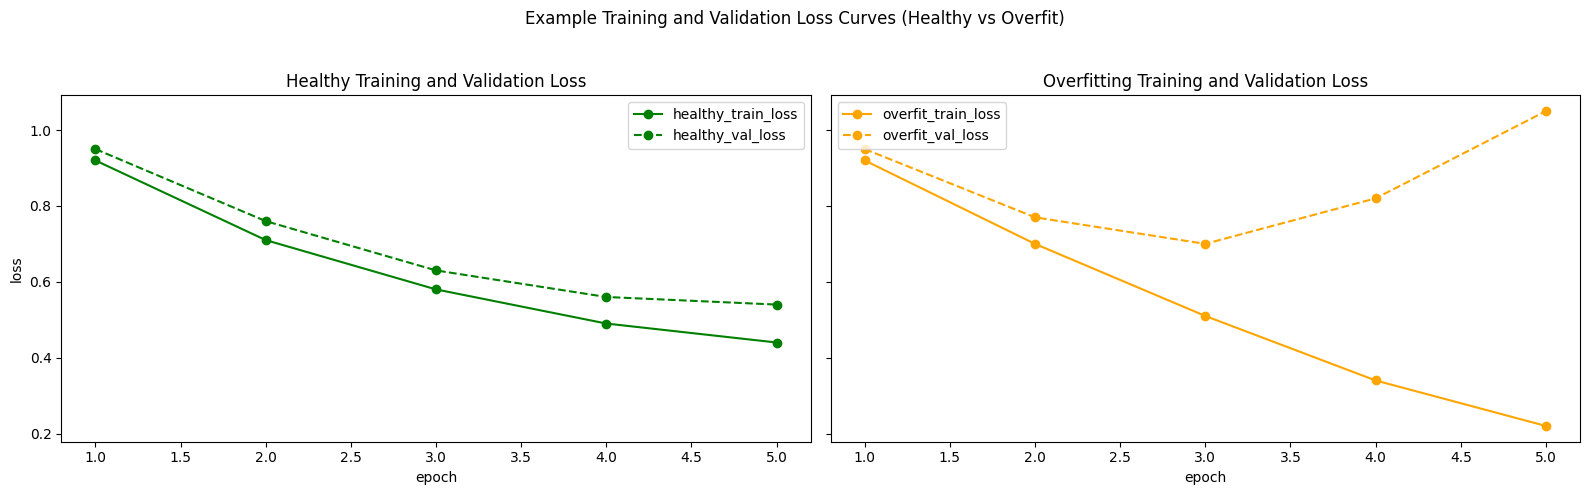

In [51]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Healthy (green: train=solid, val=dashed)
axs[0].plot(
    loss_examples["epoch"], 
    loss_examples["healthy_train_loss"], 
    marker="o", color="green", linestyle="-", label="healthy_train_loss"
)
axs[0].plot(
    loss_examples["epoch"], 
    loss_examples["healthy_val_loss"], 
    marker="o", color="green", linestyle="--", label="healthy_val_loss"
)
axs[0].set_title("Healthy Training and Validation Loss")
axs[0].set_xlabel("epoch")
axs[0].set_ylabel("loss")
axs[0].legend()

# Overfit (orange: train=solid, val=dashed)
axs[1].plot(
    loss_examples["epoch"], 
    loss_examples["overfit_train_loss"], 
    marker="o", color="orange", linestyle="-", label="overfit_train_loss"
)
axs[1].plot(
    loss_examples["epoch"], 
    loss_examples["overfit_val_loss"], 
    marker="o", color="orange", linestyle="--", label="overfit_val_loss"
)
axs[1].set_title("Overfitting Training and Validation Loss")
axs[1].set_xlabel("epoch")
axs[1].legend()

plt.suptitle("Example Training and Validation Loss Curves (Healthy vs Overfit)")
plt.tight_layout(rect=[0, 0, 1, 0.95])

In [25]:
# Early stopping logic from the chapter, demonstrated with synthetic validation losses.
val_losses = [0.95, 0.76, 0.63, 0.56, 0.54, 0.55, 0.58, 0.62]

best_val_loss = float("inf")
epochs_without_improvement = 0
patience = 3
best_epoch = None

for epoch, val_loss in enumerate(val_losses, start=1):
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        best_epoch = epoch
        print(f"Epoch {epoch}: improved validation loss to {val_loss:.3f}; save checkpoint")
    else:
        epochs_without_improvement += 1
        print(f"Epoch {epoch}: no improvement ({epochs_without_improvement}/{patience})")

    if epochs_without_improvement >= patience:
        print(f"Stopping early at epoch {epoch}. Best epoch was {best_epoch}.")
        break

Epoch 1: improved validation loss to 0.950; save checkpoint
Epoch 2: improved validation loss to 0.760; save checkpoint
Epoch 3: improved validation loss to 0.630; save checkpoint
Epoch 4: improved validation loss to 0.560; save checkpoint
Epoch 5: improved validation loss to 0.540; save checkpoint
Epoch 6: no improvement (1/3)
Epoch 7: no improvement (2/3)
Epoch 8: no improvement (3/3)
Stopping early at epoch 8. Best epoch was 5.


Text(0, 0.5, 'training loss')

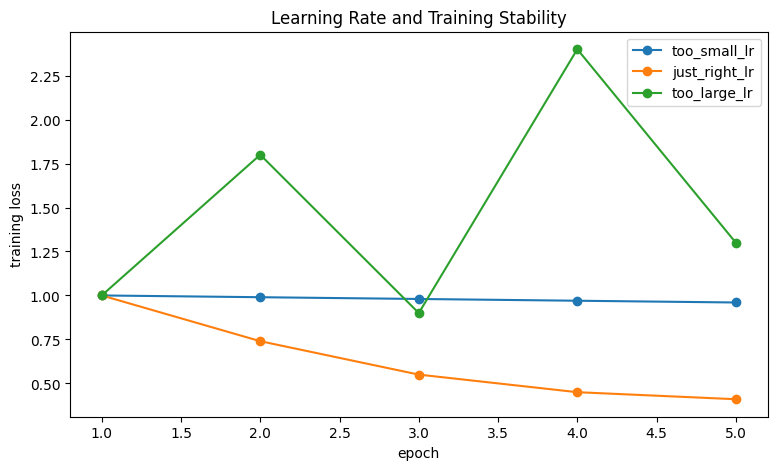

In [26]:
# Learning-rate behavior: too small, just right, and too large.
learning_rate_curves = pd.DataFrame(
    {
        "epoch": [1, 2, 3, 4, 5],
        "too_small_lr": [1.00, 0.99, 0.98, 0.97, 0.96],
        "just_right_lr": [1.00, 0.74, 0.55, 0.45, 0.41],
        "too_large_lr": [1.00, 1.80, 0.90, 2.40, 1.30],
    }
)

ax = learning_rate_curves.plot(
    x="epoch",
    y=["too_small_lr", "just_right_lr", "too_large_lr"],
    marker="o",
    figsize=(9, 5),
    title="Learning Rate and Training Stability",
)
ax.set_ylabel("training loss")

## 11. Decision Thresholds

The default threshold for binary classification is often `0.5`, but the best threshold depends on the use case. For rare critical failures, a lower threshold may increase recall at the cost of more false alarms.

In [27]:
# Use probability-like scores from the selected validation model.
if hasattr(selected_model.named_steps["model"], "predict_proba"):
    probabilities = selected_model.predict_proba(X_val)[:, 1]
else:
    probabilities = selected_model.decision_function(X_val)

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    threshold_predictions = probabilities >= threshold
    threshold_results.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_val, threshold_predictions, zero_division=0),
            "recall": recall_score(y_val, threshold_predictions, zero_division=0),
            "f1": f1_score(y_val, threshold_predictions, zero_division=0),
            "flagged_for_review": int(threshold_predictions.sum()),
        }
    )

threshold_table = pd.DataFrame(threshold_results)
threshold_table.sort_values("f1", ascending=False).head(10).round(3)

,threshold,precision,recall,f1,flagged_for_review
14,0.80,1.000,0.8,0.889,8
13,0.75,1.000,0.8,0.889,8
12,0.70,1.000,0.8,0.889,8
8,0.50,0.889,0.8,0.842,9
9,0.55,0.889,0.8,0.842,9
11,0.65,0.889,0.8,0.842,9
10,0.60,0.889,0.8,0.842,9
15,0.85,1.000,0.7,0.824,7
16,0.90,1.000,0.7,0.824,7
7,0.45,0.800,0.8,0.800,10


In [28]:
recall_focused_threshold = 0.25
recall_focused_predictions = probabilities >= recall_focused_threshold

print(f"Threshold: {recall_focused_threshold}")
print(classification_report(y_val, recall_focused_predictions, target_names=["pass", "fail"]))
print("Confusion matrix:")
print(confusion_matrix(y_val, recall_focused_predictions))

Threshold: 0.25
              precision    recall  f1-score   support

        pass       0.99      0.95      0.97       140
        fail       0.53      0.80      0.64        10

    accuracy                           0.94       150
   macro avg       0.76      0.88      0.80       150
weighted avg       0.96      0.94      0.95       150

Confusion matrix:
[[133   7]
 [  2   8]]


## 12. Ensemble Models: Bagging, Boosting, and Stacking

Ensembles combine multiple models. They often improve performance, but they also add complexity.

In [29]:
ensemble_models = {
    "Bagging - Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "Boosting - HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        random_state=RANDOM_SEED,
    ),
    "Stacking": StackingClassifier(
        estimators=[
            ("rf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)),
            ("svm", make_pipeline(StandardScaler(), SVC(probability=True, random_state=RANDOM_SEED))),
        ],
        final_estimator=LogisticRegression(max_iter=1000),
        cv=3,
    ),
}

ensemble_results = []

for name, estimator in ensemble_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", estimator),
        ]
    )
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_val)
    ensemble_results.append(
        {
            "ensemble_strategy": name,
            "precision": precision_score(y_val, predictions, zero_division=0),
            "recall": recall_score(y_val, predictions, zero_division=0),
            "f1": f1_score(y_val, predictions, zero_division=0),
        }
    )

pd.DataFrame(ensemble_results).sort_values("f1", ascending=False).round(3)

,ensemble_strategy,precision,recall,f1
0,Bagging - Random Forest,1.0,0.7,0.824
1,Boosting - HistGradientBoosting,1.0,0.7,0.824
2,Stacking,1.0,0.7,0.824


## 14. GPU and Distributed Training Concepts

These examples mirror the chapter's PyTorch device and distributed-training snippets. The GPU check can be run directly. The distributed-training sketch is printed as reference code because real DDP training should be launched as a script with `torchrun`, not from a normal notebook cell.

In [35]:
try:
    import torch

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"PyTorch device: {device}")

    if device == "cuda":
        print(f"GPU count: {torch.cuda.device_count()}")
        print(f"Current GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("No CUDA GPU detected. CPU is fine for the sklearn examples in this notebook.")
except ImportError:
    print("PyTorch is not installed. Install it with: pip install torch")

PyTorch device: cpu
No CUDA GPU detected. CPU is fine for the sklearn examples in this notebook.


In [36]:
ddp_launch_command = "torchrun --nproc_per_node=4 train.py --epochs 30 --batch-size 128"

conceptual_ddp_code = """
import os
import torch
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel

# This belongs in a training script launched with torchrun.
dist.init_process_group(backend="nccl")

local_rank = int(os.environ["LOCAL_RANK"])
torch.cuda.set_device(local_rank)

model = build_model().to(local_rank)
model = DistributedDataParallel(model, device_ids=[local_rank])
"""

print("Launch command:")
print(ddp_launch_command)
print("\nConceptual DDP setup:")
print(conceptual_ddp_code)

Launch command:
torchrun --nproc_per_node=4 train.py --epochs 30 --batch-size 128

Conceptual DDP setup:

import os
import torch
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel

# This belongs in a training script launched with torchrun.
dist.init_process_group(backend="nccl")

local_rank = int(os.environ["LOCAL_RANK"])
torch.cuda.set_device(local_rank)

model = build_model().to(local_rank)
model = DistributedDataParallel(model, device_ids=[local_rank])



## 15. Reproducibility and Final Test Evaluation

After selecting a model and threshold using training/validation data, evaluate once on the final test set. Also record enough information to understand and reproduce the run.

In [37]:
# Re-seed common libraries for reproducibility.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

try:
    import torch

    torch.manual_seed(RANDOM_SEED)
    print("Set Python, NumPy, and PyTorch seeds.")
except ImportError:
    print("Set Python and NumPy seeds. PyTorch is not installed.")

run_record = {
    "random_seed": RANDOM_SEED,
    "feature_columns": feature_columns,
    "target": target,
    "split_strategy": "stratified 70/15/15",
    "selected_model": selected_model_name,
    "threshold_example": recall_focused_threshold,
}

run_record

Set Python, NumPy, and PyTorch seeds.


{'random_seed': 42,
 'feature_columns': ['voltage',
  'travel_speed',
  'temperature',
  'mean_pixel',
  'material',
  'shift'],
 'target': 'inspection_result',
 'split_strategy': 'stratified 70/15/15',
 'selected_model': 'Logistic Regression',
 'threshold_example': 0.25}

In [38]:
# Final test evaluation. In a real project, do this once after model selection.
test_probabilities = selected_model.predict_proba(X_test)[:, 1]
test_predictions = test_probabilities >= recall_focused_threshold

print(f"Final test evaluation using threshold {recall_focused_threshold}")
print(classification_report(y_test, test_predictions, target_names=["pass", "fail"]))
print("Confusion matrix:")
print(confusion_matrix(y_test, test_predictions))

Final test evaluation using threshold 0.25
              precision    recall  f1-score   support

        pass       0.98      0.91      0.94       141
        fail       0.35      0.78      0.48         9

    accuracy                           0.90       150
   macro avg       0.67      0.84      0.71       150
weighted avg       0.95      0.90      0.92       150

Confusion matrix:
[[128  13]
 [  2   7]]


## 16. Practice Extensions

Try these modifications after running the notebook:

1. Change the class imbalance in `make_classification()` and rerun the split and threshold sections.
2. Compare F1 with recall-focused model selection.
3. Add `class_weight="balanced"` to Random Forest and compare results.
4. Change the threshold to meet a target review capacity.
5. Add a new categorical feature and update the preprocessing pipeline.
6. Replace the selected model with the best grid-search model for final test evaluation.
7. Log the threshold table as an MLflow artifact.
8. Convert the training workflow into a standalone `train.py` script.